# Mô hình 4: Custom Transformer Encoder
## Phân loại Phản hồi Sinh viên Tiếng Việt

**Bài toán**: Phân loại cảm xúc phản hồi sinh viên (3 lớp: Negative / Neutral / Positive)

**Kiến trúc Custom Transformer**:
- Embedding Layer
- Positional Encoding (sin/cos)
- Transformer Encoder (3 layers, 4 heads, dim_ff=256)
- Masked Mean Pooling (bỏ qua padding)
- Dropout + Fully Connected

> Vaswani et al. (2017). *Attention Is All You Need*. NeurIPS.

In [1]:
# ===================== CÀI ĐẶT THƯ VIỆN =====================
# !pip install torch pandas numpy scikit-learn matplotlib seaborn

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import re
import time
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Sử dụng thiết bị: {device}')

Sử dụng thiết bị: cpu


## 1. Chuẩn bị Dữ liệu

In [2]:
# ===================== TẢI DỮ LIỆU =====================
train_df = pd.read_csv('data/train.csv')
val_df   = pd.read_csv('data/val.csv')
test_df  = pd.read_csv('data/test.csv')

CLASSES = ['Negative', 'Neutral', 'Positive']
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('\nPhân phối nhãn (Train):')
print(train_df['label'].value_counts().sort_index())

Train: 1467 | Val: 210 | Test: 423

Phân phối nhãn (Train):
label
0    489
1    489
2    489
Name: count, dtype: int64


In [3]:
# ===================== TIỀN XỬ LÝ & VOCAB =====================
def clean_text(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^\w\s\u00C0-\u024F\u1E00-\u1EFF]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def tokenize(text):
    return clean_text(text).split()

class Vocabulary:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}

    def build_vocab(self, sentences):
        counter = Counter(token for tokens in sentences for token in tokens)
        for word, freq in counter.items():
            if freq >= self.min_freq:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, tokens, max_len=50):
        ids = [self.word2idx.get(t, 1) for t in tokens[:max_len]]
        ids += [0] * (max_len - len(ids))
        return ids

    def __len__(self): return len(self.word2idx)

vocab = Vocabulary(min_freq=2)
vocab.build_vocab(train_df['text'].apply(tokenize))
print(f'Vocabulary size: {len(vocab)}')

MAX_LEN = 50
BATCH_SIZE = 32

class FeedbackDataset(Dataset):
    def __init__(self, df, vocab, max_len=50):
        self.texts  = df['text'].values
        self.labels = df['label'].values
        self.vocab  = vocab
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        tokens = tokenize(str(self.texts[idx]))
        encoded = self.vocab.encode(tokens, self.max_len)
        return {
            'input_ids': torch.tensor(encoded, dtype=torch.long),
            'labels':    torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(FeedbackDataset(train_df, vocab, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(FeedbackDataset(val_df,   vocab, MAX_LEN), batch_size=BATCH_SIZE)
test_loader  = DataLoader(FeedbackDataset(test_df,  vocab, MAX_LEN), batch_size=BATCH_SIZE)
print('DataLoaders sẵn sàng!')

Vocabulary size: 481
DataLoaders sẵn sàng!


## 2. Kiến trúc Mô hình Transformer

In [4]:
# ===================== MÔ HÌNH CUSTOM TRANSFORMER =====================
class PositionalEncoding(nn.Module):
    """
    Positional Encoding sử dụng sin/cos (Vaswani et al. 2017).
    """
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position  = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term  = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: [batch, seq_len, d_model]
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TransformerClassifier(nn.Module):
    """
    Custom Transformer Encoder cho phân loại văn bản.
    - 3 Transformer Encoder layers
    - 4 Attention Heads
    - Masked Mean Pooling (bỏ qua padding tokens)
    """
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=3,
                 dim_feedforward=256, output_dim=3, dropout=0.1, pad_idx=0):
        super().__init__()
        self.d_model    = d_model
        self.pad_idx    = pad_idx
        self.embedding  = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_encoder = PositionalEncoding(d_model, dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: [batch, seq_len]
        pad_mask = (src == self.pad_idx)              # True ở vị trí padding
        src = self.embedding(src) * math.sqrt(self.d_model)
        src = self.pos_encoder(src)                   # [batch, seq_len, d_model]
        output = self.transformer_encoder(src, src_key_padding_mask=pad_mask)
        # Masked Mean Pooling (bỏ qua các token padding)
        mask = (~pad_mask).float().unsqueeze(-1)       # [batch, seq_len, 1]
        pooled = (output * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return self.fc(self.dropout(pooled))

model = TransformerClassifier(vocab_size=len(vocab), d_model=128, nhead=4,
                               num_layers=3, dim_feedforward=256,
                               output_dim=3, dropout=0.1).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tổng tham số: {total_params:,}')
print(f'Kích thước mô hình: {total_params * 4 / 1024**2:.2f} MB')

Tổng tham số: 459,395
Kích thước mô hình: 1.75 MB


## 3. Huấn luyện

In [5]:
# ===================== TRAINING LOOP =====================
EPOCHS   = 15
LR       = 1e-3
PATIENCE = 5

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print('='*60)
print('Bắt đầu huấn luyện Custom Transformer...')
print('='*60)
start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    train_correct, train_total = 0, 0
    for batch in train_loader:
        x = batch['input_ids'].to(device)
        y = batch['labels'].to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward(); optimizer.step()
        train_loss += loss.item()
        train_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        train_total += y.size(0)
    train_loss /= len(train_loader)
    train_acc = train_correct / train_total

    model.eval()
    val_loss = 0
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            x = batch['input_ids'].to(device)
            y = batch['labels'].to(device)
            logits = model(x)
            val_loss += criterion(logits, y).item()
            val_correct += (torch.argmax(logits, dim=1) == y).sum().item()
            val_total += y.size(0)
    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'Transformer.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            pass
        # print(f'Early stopping tại epoch {epoch+1}')
        # # break # Disabled as requested

total_time = time.time() - start_time
print(f'\nThời gian huấn luyện: {total_time:.1f}s')
model.load_state_dict(torch.load('Transformer.pt', map_location=device))
print('Đã load mô hình tốt nhất!')

Bắt đầu huấn luyện Custom Transformer...


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Epoch  1/15 | Train Loss: 0.7494 | Val Loss: 0.6908 | Train Acc: 0.6503 | Val Acc: 0.7381
Epoch  2/15 | Train Loss: 0.1490 | Val Loss: 1.2375 | Train Acc: 0.9502 | Val Acc: 0.6095
Epoch  3/15 | Train Loss: 0.0841 | Val Loss: 1.5117 | Train Acc: 0.9700 | Val Acc: 0.5810
Epoch  4/15 | Train Loss: 0.0266 | Val Loss: 2.1823 | Train Acc: 0.9925 | Val Acc: 0.5714
Epoch  5/15 | Train Loss: 0.0190 | Val Loss: 2.4106 | Train Acc: 0.9952 | Val Acc: 0.5381
Epoch  6/15 | Train Loss: 0.0162 | Val Loss: 2.2400 | Train Acc: 0.9918 | Val Acc: 0.6381
Epoch  7/15 | Train Loss: 0.0487 | Val Loss: 2.7923 | Train Acc: 0.9823 | Val Acc: 0.5762
Epoch  8/15 | Train Loss: 0.0278 | Val Loss: 2.5042 | Train Acc: 0.9891 | Val Acc: 0.6286
Epoch  9/15 | Train Loss: 0.0327 | Val Loss: 2.6623 | Train Acc: 0.9884 | Val Acc: 0.5714
Epoch 10/15 | Train Loss: 0.0186 | Val Loss: 2.4125 | Train Acc: 0.9952 | Val Acc: 0.6238
Epoch 11/15 | Train Loss: 0.0318 | Val Loss: 2.1174 | Train Acc: 0.9898 | Val Acc: 0.6048
Epoch 12/1

## 4. Đánh giá trên Tập Test

In [6]:
from IPython.display import display
# ===================== ĐÁNH GIÁ =====================
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        x = batch['input_ids'].to(device)
        y = batch['labels'].to(device)
        preds = torch.argmax(model(x), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('\n' + '='*60)
print('KẾT QUẢ MÔ HÌNH: CUSTOM TRANSFORMER ENCODER')
print('='*60)
print(classification_report(all_labels, all_preds, target_names=CLASSES))

# Lưu bảng metrics vào CSV và in ra DataFrame
report_dict = classification_report(all_labels, all_preds, target_names=CLASSES, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df)
report_df.to_csv('Transformer_metrics.csv', encoding='utf-8-sig')


KẾT QUẢ MÔ HÌNH: CUSTOM TRANSFORMER ENCODER
              precision    recall  f1-score   support

    Negative       0.84      0.72      0.78       141
     Neutral       0.66      0.74      0.70       141
    Positive       0.73      0.73      0.73       141

    accuracy                           0.73       423
   macro avg       0.74      0.73      0.73       423
weighted avg       0.74      0.73      0.73       423



,precision,recall,f1-score,support
Negative,0.836066,0.723404,0.775665,141.000000
Neutral,0.660377,0.744681,0.700000,141.000000
Positive,0.725352,0.730496,0.727915,141.000000
accuracy,0.732861,0.732861,0.732861,0.732861
macro avg,0.740598,0.732861,0.734527,423.000000
weighted avg,0.740598,0.732861,0.734527,423.000000


## 5. Trực quan hóa Kết quả

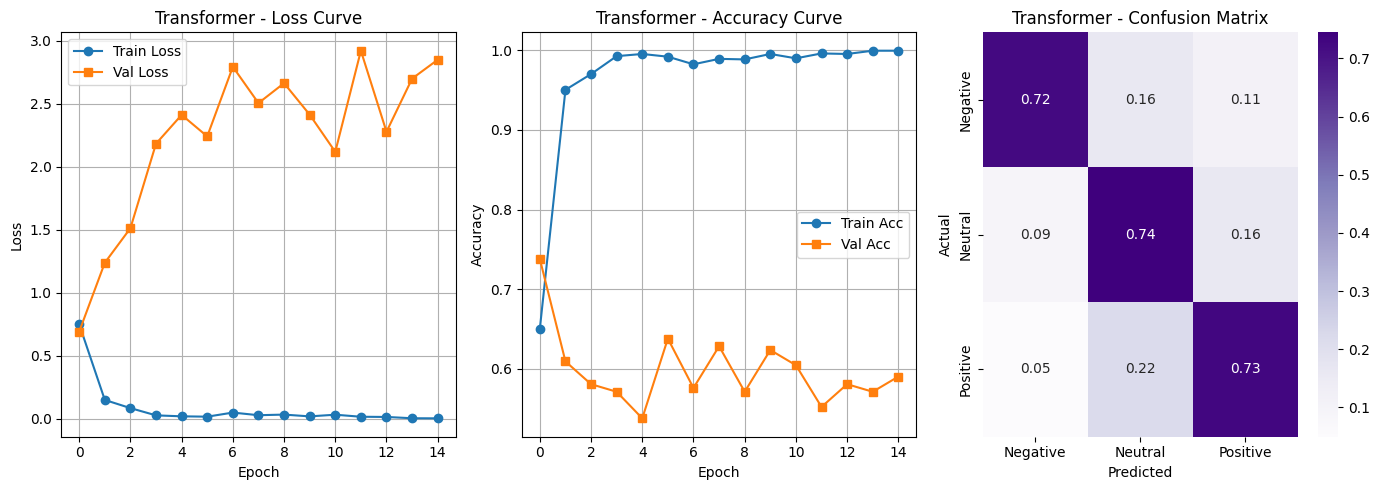

Đã lưu kết quả vào Transformer_results.png


In [7]:
# ===================== VISUALIZATION =====================
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'],   label='Val Loss',   marker='s')
axes[0].set_title('Transformer - Loss Curve')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

# Accuracy curve
axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'],   label='Val Acc',   marker='s')
axes[1].set_title('Transformer - Accuracy Curve')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)


cm = confusion_matrix(all_labels, all_preds, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Purples',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[2])
axes[2].set_title('Transformer - Confusion Matrix')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('Transformer_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Đã lưu kết quả vào Transformer_results.png')